# Backtesting: A Visual Guide

## What is Backtesting?

**Backtesting** is the process of testing a trading strategy on historical data to evaluate its performance before deploying it with real capital.

## Key Metrics to Visualize

| Visual | Purpose |
|--------|---------|
| **Equity Curve** | Overall performance trajectory |
| **Drawdown Chart** | Peak-to-trough losses over time |
| **Monthly Heatmap** | Seasonal patterns in returns |
| **Rolling Sharpe/Vol** | Stability of risk-adjusted returns |
| **Trade PnL + Underwater** | Trade-level granularity |
| **Dashboard** | All-in-one summary view |

## Assumptions & Pitfalls

- **Look-ahead bias**: Never use future data that wouldn't be available at decision time
- **Survivorship bias**: Include delisted assets if testing equities
- **Transaction costs**: Always model commissions, slippage, and spreads
- **Overfitting**: Too many parameters = poor out-of-sample performance

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ============================================
# Generate Synthetic Backtest Data
# ============================================

n_days = 756  # ~3 years of trading days
dates = pd.date_range(start='2022-01-01', periods=n_days, freq='B')

# Benchmark returns
benchmark_returns = np.random.normal(0.0004, 0.012, n_days)

# Strategy returns with alpha and market beta
alpha = 0.0003
beta = 0.6
strategy_returns = alpha + beta * benchmark_returns + np.random.normal(0, 0.008, n_days)

# Inject drawdown periods
strategy_returns[100:115] -= 0.015
strategy_returns[300:320] -= 0.012
strategy_returns[550:570] -= 0.018

# Inject winning streaks
strategy_returns[150:155] += 0.02
strategy_returns[400:405] += 0.015

# Transaction costs (~1 trade every 3 days)
trade_days = np.random.choice(n_days, n_days // 3, replace=False)
strategy_returns[trade_days] -= 0.0005

# Build DataFrame
df = pd.DataFrame({
    'date': dates,
    'strategy': strategy_returns,
    'benchmark': benchmark_returns
})
df.set_index('date', inplace=True)

# Cumulative returns
df['strategy_cum'] = (1 + df['strategy']).cumprod()
df['benchmark_cum'] = (1 + df['benchmark']).cumprod()

print("Data generated!")
print(f"Shape: {df.shape}")
print(f"Range: {df.index[0].date()} to {df.index[-1].date()}")


Data generated!
Shape: (756, 4)
Range: 2022-01-03 to 2024-11-25


## Equity Curve

The equity curve shows the cumulative growth of $1 invested in the strategy versus the benchmark. It is the single most important backtesting chart.

**What to look for:**
- Smooth upward slope = good
- Large gaps/drops = high volatility or drawdowns
- Consistent outperformance vs benchmark = alpha

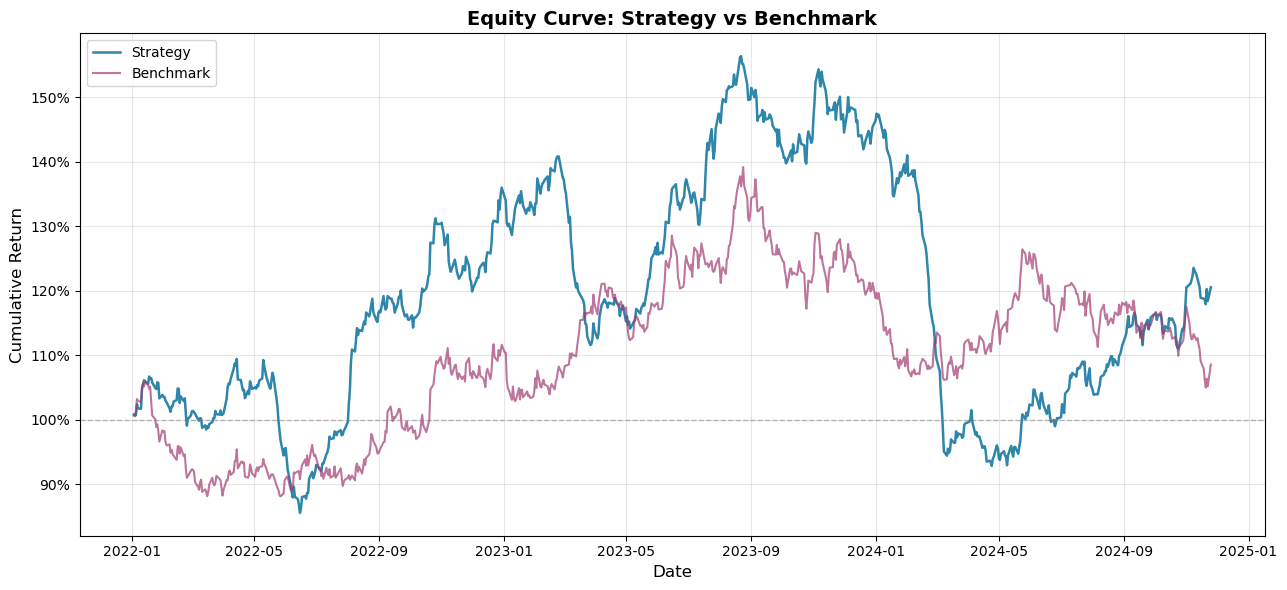

In [32]:
# ============================================
# Equity Curve
# ============================================

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(df.index, df['strategy_cum'], '-', color='#2E86AB', linewidth=1.8, label='Strategy')
ax.plot(df.index, df['benchmark_cum'], '-', color='#A23B72', linewidth=1.5,
        alpha=0.7, label='Benchmark')

ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return', fontsize=12)
ax.set_title('Equity Curve: Strategy vs Benchmark', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Format y-axis as percentage
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()


## Drawdown Chart

Drawdown measures the decline from a historical peak. It answers: *"If I invested at the worst possible time, how much would I lose?"*

**Key insight:** A strategy can have positive total returns but still experience severe drawdowns that cause investors to abandon it.


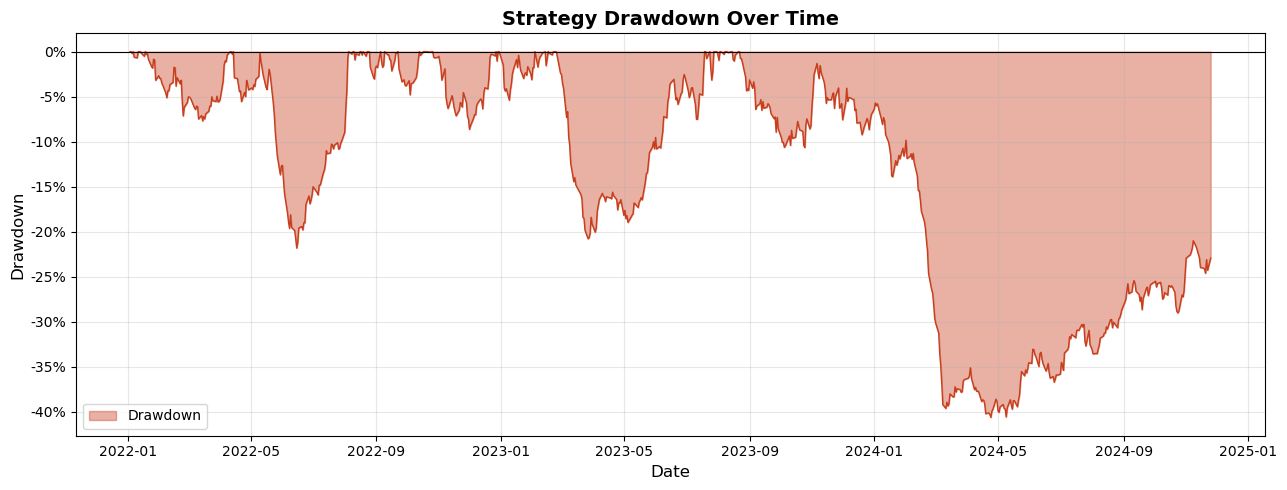

Max Drawdown: -40.62% on 2024-04-24


In [33]:
# ============================================
# Drawdown Chart
# ============================================

running_max = df['strategy_cum'].cummax()
drawdown = (df['strategy_cum'] - running_max) / running_max

fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(df.index, drawdown, 0, color='#C73E1D', alpha=0.4, label='Drawdown')
ax.plot(df.index, drawdown, '-', color='#C73E1D', linewidth=1)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Drawdown', fontsize=12)
ax.set_title('Strategy Drawdown Over Time', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

max_dd = drawdown.min()
max_dd_date = drawdown.idxmin()
print(f"Max Drawdown: {max_dd:.2%} on {max_dd_date.date()}")


## Monthly Returns Heatmap

A heatmap reveals seasonal patterns and consistency. Green months = positive returns, red months = negative returns.

**What to look for:**
- Clustering of red = potential systematic flaw
- Consistent green = robust strategy
- Extreme single months = tail risk

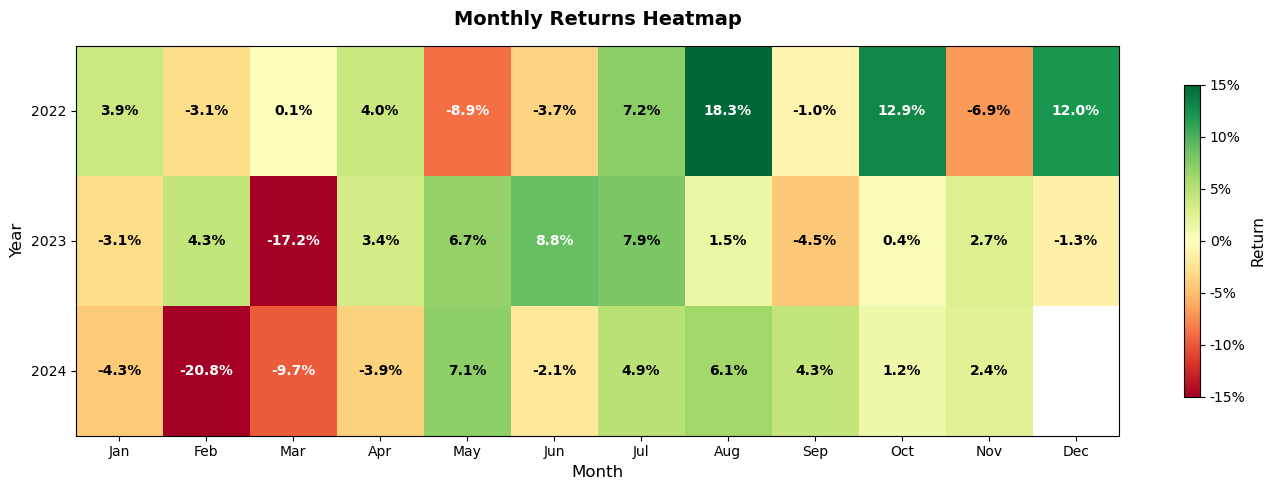

In [34]:
# ============================================
# Monthly Returns Heatmap (matplotlib only)
# ============================================

monthly = df['strategy'].resample('ME').apply(lambda x: (1 + x).prod() - 1)
monthly_df = monthly.to_frame('returns')
monthly_df['year'] = monthly_df.index.year
monthly_df['month'] = monthly_df.index.month

pivot = monthly_df.pivot(index='year', columns='month', values='returns')
pivot.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(14, 5))

n_rows, n_cols = pivot.shape
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=-0.15, vmax=0.15)

ax.set_xticks(np.arange(n_cols))
ax.set_yticks(np.arange(n_rows))
ax.set_xticklabels(pivot.columns)
ax.set_yticklabels(pivot.index)

for i in range(n_rows):
    for j in range(n_cols):
        val = pivot.iloc[i, j]
        if not np.isnan(val):
            text_color = 'white' if abs(val) > 0.08 else 'black'
            ax.text(j, i, f'{val:.1%}', ha='center', va='center',
                    color=text_color, fontsize=10, fontweight='bold')

ax.set_title('Monthly Returns Heatmap', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Year', fontsize=12)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Return', fontsize=11)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()


## Rolling Sharpe Ratio & Volatility

Static metrics hide time-varying behavior. Rolling windows reveal whether the strategy's edge is stable or deteriorating.

| Metric | Formula | Interpretation |
|--------|---------|---------------|
| **Sharpe Ratio** | $(R_p - R_f) / \sigma_p$ | Risk-adjusted return |
| **Volatility** | $\sigma \times \sqrt{252}$ | Annualized standard deviation |


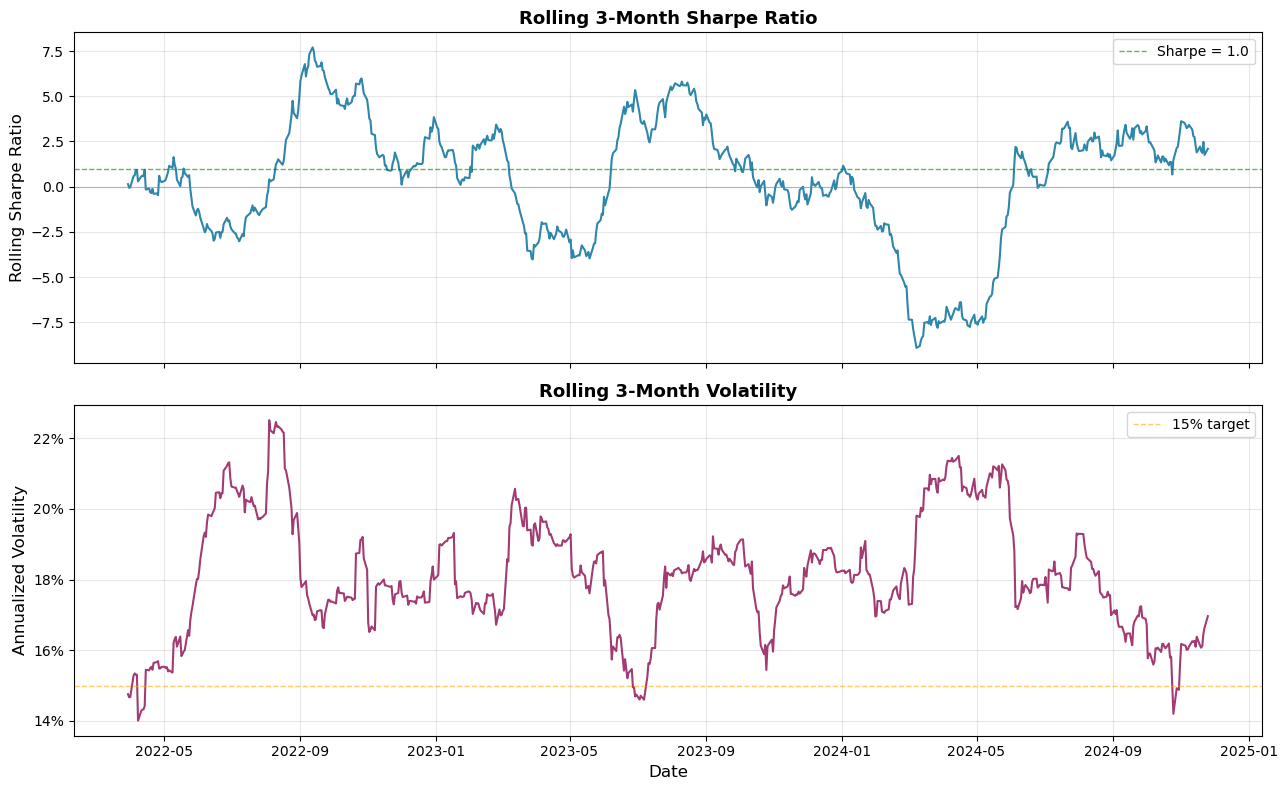

In [35]:
# ============================================
# Rolling Sharpe & Volatility
# ============================================

window = 63  # ~3 months
risk_free = 0.02 / 252

rolling_mean = df['strategy'].rolling(window).mean()
rolling_std = df['strategy'].rolling(window).std()
rolling_sharpe = (rolling_mean - risk_free) / rolling_std * np.sqrt(252)
rolling_vol = rolling_std * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Rolling Sharpe
ax = axes[0]
ax.plot(df.index, rolling_sharpe, '-', color='#2E86AB', linewidth=1.5)
ax.axhline(y=1.0, color='green', linestyle='--', linewidth=1, alpha=0.6, label='Sharpe = 1.0')
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Rolling Sharpe Ratio', fontsize=12)
ax.set_title('Rolling 3-Month Sharpe Ratio', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Rolling Volatility
ax = axes[1]
ax.plot(df.index, rolling_vol, '-', color='#A23B72', linewidth=1.5)
ax.axhline(y=0.15, color='orange', linestyle='--', linewidth=1, alpha=0.6, label='15% target')
ax.set_ylabel('Annualized Volatility', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_title('Rolling 3-Month Volatility', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Trade-Level Analysis

When trade-level data is available, two critical plots emerge:

1. **Individual Trade PnL**: Shows win/loss distribution and streaks
2. **Underwater Curve (trade-level)**: Drawdown measured in trade space rather than time space

**Key metrics:**
- **Win Rate**: % of profitable trades
- **Profit Factor**: Gross profits / Gross losses
- **Avg Win / Avg Loss**: Reward-to-risk per trade

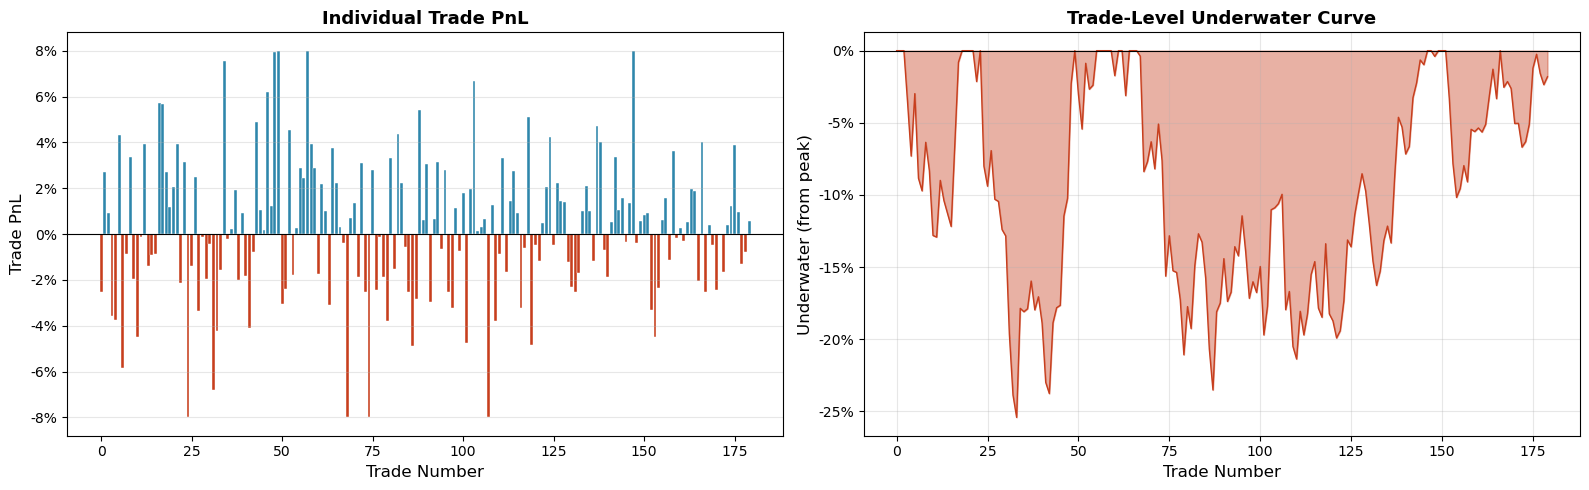

Win Rate: 53.9%
Avg Win: 2.50%
Avg Loss: -2.34%
Profit Factor: 1.25


In [36]:
# ============================================
# Trade PnL + Underwater Curve
# ============================================

np.random.seed(123)
n_trades_sim = 180
trade_pnl = np.random.normal(0.002, 0.025, n_trades_sim)

# Fat tails
outliers = np.random.choice(n_trades_sim, 15, replace=False)
trade_pnl[outliers] *= 3
trade_pnl = np.clip(trade_pnl, -0.08, 0.08)

trade_cum = np.cumsum(trade_pnl)
trade_running_max = np.maximum.accumulate(trade_cum)
trade_underwater = trade_cum - trade_running_max

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Trade PnL bars
ax = axes[0]
colors = ['#C73E1D' if p < 0 else '#2E86AB' for p in trade_pnl]
ax.bar(range(len(trade_pnl)), trade_pnl, color=colors, edgecolor='white', linewidth=0.3)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel('Trade Number', fontsize=12)
ax.set_ylabel('Trade PnL', fontsize=12)
ax.set_title('Individual Trade PnL', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, alpha=0.3, axis='y')

# Underwater curve
ax = axes[1]
ax.fill_between(range(len(trade_pnl)), trade_underwater, 0, color='#C73E1D', alpha=0.4)
ax.plot(range(len(trade_pnl)), trade_underwater, '-', color='#C73E1D', linewidth=1)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel('Trade Number', fontsize=12)
ax.set_ylabel('Underwater (from peak)', fontsize=12)
ax.set_title('Trade-Level Underwater Curve', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

win_rate = (trade_pnl > 0).mean()
avg_win = trade_pnl[trade_pnl > 0].mean() if (trade_pnl > 0).any() else 0
avg_loss = trade_pnl[trade_pnl < 0].mean() if (trade_pnl < 0).any() else 0
profit_factor = abs(trade_pnl[trade_pnl > 0].sum() / trade_pnl[trade_pnl < 0].sum()) if trade_pnl[trade_pnl < 0].sum() != 0 else float('inf')

print(f"Win Rate: {win_rate:.1%}")
print(f"Avg Win: {avg_win:.2%}")
print(f"Avg Loss: {avg_loss:.2%}")
print(f"Profit Factor: {profit_factor:.2f}")


## Performance Dashboard

A consolidated dashboard combines all critical views into one figure for presentations or reports. It uses `matplotlib.gridspec` to arrange subplots in a grid.


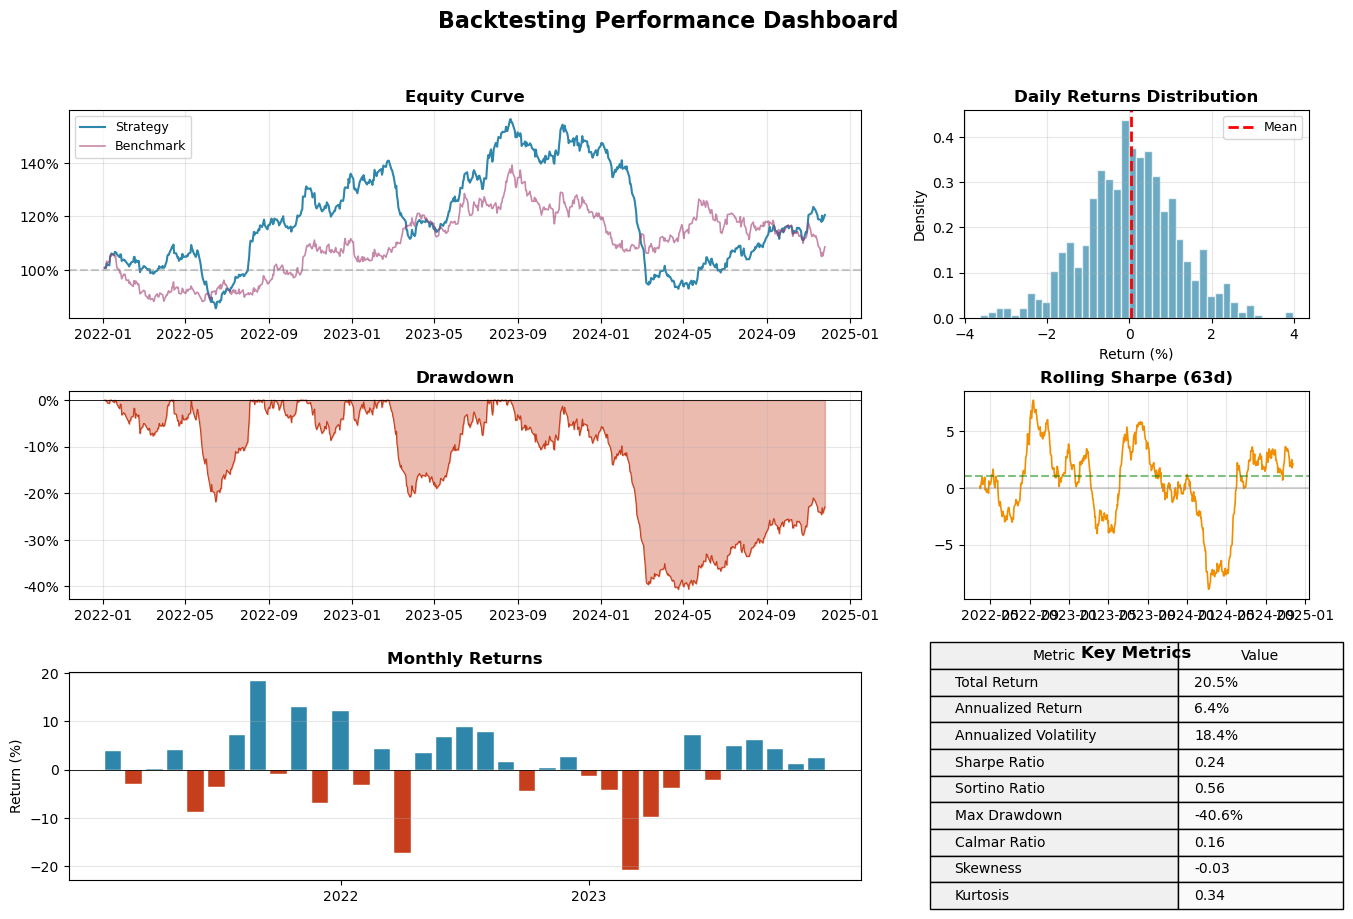

In [41]:
# ============================================
# Performance Dashboard
# ============================================

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# --- Equity Curve ---
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(df.index, df['strategy_cum'], '-', color='#2E86AB', linewidth=1.5, label='Strategy')
ax1.plot(df.index, df['benchmark_cum'], '-', color='#A23B72', linewidth=1.2,
         alpha=0.6, label='Benchmark')
ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.4)
ax1.set_title('Equity Curve', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax1.grid(True, alpha=0.3)

# --- Return Distribution ---
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(df['strategy'] * 100, bins=40, color='#2E86AB', edgecolor='white',
         alpha=0.7, density=True)
ax2.axvline(x=df['strategy'].mean() * 100, color='red', linestyle='--',
            linewidth=2, label='Mean')
ax2.set_title('Daily Returns Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Return (%)')
ax2.set_ylabel('Density')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Drawdown ---
ax3 = fig.add_subplot(gs[1, :2])
ax3.fill_between(df.index, drawdown, 0, color='#C73E1D', alpha=0.35)
ax3.plot(df.index, drawdown, '-', color='#C73E1D', linewidth=0.8)
ax3.axhline(y=0, color='black', linewidth=0.6)
ax3.set_title('Drawdown', fontsize=12, fontweight='bold')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax3.grid(True, alpha=0.3)

# --- Rolling Sharpe ---
ax4 = fig.add_subplot(gs[1, 2])
ax4.plot(df.index, rolling_sharpe, '-', color='#F18F01', linewidth=1.2)
ax4.axhline(y=1, color='green', linestyle='--', alpha=0.5)
ax4.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax4.set_title('Rolling Sharpe (63d)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# --- Monthly Returns Bar ---
ax5 = fig.add_subplot(gs[2, :2])
monthly_rets = df['strategy'].resample('ME').apply(lambda x: (1 + x).prod() - 1)
colors = ['#2E86AB' if r >= 0 else '#C73E1D' for r in monthly_rets]
ax5.bar(range(len(monthly_rets)), monthly_rets * 100, color=colors,
        edgecolor='white', linewidth=0.3)
ax5.axhline(y=0, color='black', linewidth=0.6)
ax5.set_title('Monthly Returns', fontsize=12, fontweight='bold')
ax5.set_ylabel('Return (%)')
year_starts = [i for i, (p, c) in enumerate(zip(monthly_rets.index[:-1],
                                                  monthly_rets.index[1:]))
               if p.year != c.year]
ax5.set_xticks(year_starts)
ax5.set_xticklabels([monthly_rets.index[i].year for i in year_starts])
ax5.grid(True, alpha=0.3, axis='y')

# --- Metrics Table ---
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')

total_ret = df['strategy_cum'].iloc[-1] - 1
ann_ret = (df['strategy_cum'].iloc[-1] ** (252 / len(df))) - 1
ann_vol = df['strategy'].std() * np.sqrt(252)
sharpe = (ann_ret - 0.02) / ann_vol if ann_vol > 0 else 0
sortino = ann_ret / (df['strategy'][df['strategy'] < 0].std() * np.sqrt(252)) if len(df['strategy'][df['strategy'] < 0]) > 0 else 0
calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0

metrics = [
    ['Total Return', f'{total_ret:.1%}'],
    ['Annualized Return', f'{ann_ret:.1%}'],
    ['Annualized Volatility', f'{ann_vol:.1%}'],
    ['Sharpe Ratio', f'{sharpe:.2f}'],
    ['Sortino Ratio', f'{sortino:.2f}'],
    ['Max Drawdown', f'{max_dd:.1%}'],
    ['Calmar Ratio', f'{calmar:.2f}'],
    ['Skewness', f'{df["strategy"].skew():.2f}'],
    ['Kurtosis', f'{df["strategy"].kurtosis():.2f}'],
]

table = ax6.table(cellText=metrics, colLabels=['Metric', 'Value'],
                  cellLoc='left', loc='center', colWidths=[0.6, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)
for i in range(len(metrics) + 1):
    table[(i, 0)].set_facecolor('#f0f0f0')
    table[(i, 1)].set_facecolor('#fafafa')
ax6.set_title('Key Metrics', fontsize=12, fontweight='bold', pad=10)

plt.suptitle('Backtesting Performance Dashboard', fontsize=16, fontweight='bold', y=0.98)
plt.show()


## Summary: How to Read These Charts

| Chart | Red Flags | Green Flags |
|-------|-----------|-------------|
| **Equity Curve** | Flat or declining long-term | Consistent upward slope |
| **Drawdown** | Deep, prolonged troughs | Shallow, quick recoveries |
| **Heatmap** | Clustered red months | Mixed green/red, no clustering |
| **Rolling Sharpe** | Dropping below 0 for long periods | Stable above 1.0 |
| **Trade PnL** | Win rate < 40%, profit factor < 1 | Win rate > 50%, PF > 1.5 |
| **Dashboard** | Any metric in bottom 20th percentile | All metrics above median |

## Next Steps

1. **Walk-forward analysis**: Test on rolling out-of-sample windows
2. **Monte Carlo simulation**: Shuffle returns to stress-test
3. **Regime analysis**: Split by bull/bear/volatile markets
4. **Sensitivity analysis**: Vary parameters to check robustness

In [42]:
# ============================================
# Final: Key Metrics Summary
# ============================================

print("=" * 55)
print("BACKTESTING PERFORMANCE SUMMARY")
print("=" * 55)

summary_metrics = {
    'Total Return': f'{total_ret:.2%}',
    'Annualized Return': f'{ann_ret:.2%}',
    'Annualized Volatility': f'{ann_vol:.2%}',
    'Sharpe Ratio': f'{sharpe:.2f}',
    'Sortino Ratio': f'{sortino:.2f}',
    'Max Drawdown': f'{max_dd:.2%}',
    'Calmar Ratio': f'{calmar:.2f}',
    'Skewness': f'{df["strategy"].skew():.2f}',
    'Kurtosis': f'{df["strategy"].kurtosis():.2f}',
    'Win Rate (daily)': f'{(df["strategy"] > 0).mean():.1%}',
    'Best Day': f'{df["strategy"].max():.2%}',
    'Worst Day': f'{df["strategy"].min():.2%}',
}

for k, v in summary_metrics.items():
    print(f"{k:<25} {v:>15}")

print("=" * 55)


BACKTESTING PERFORMANCE SUMMARY
Total Return                       20.54%
Annualized Return                   6.42%
Annualized Volatility              18.36%
Sharpe Ratio                         0.24
Sortino Ratio                        0.56
Max Drawdown                      -40.62%
Calmar Ratio                         0.16
Skewness                            -0.03
Kurtosis                             0.34
Win Rate (daily)                    50.9%
Best Day                            3.98%
Worst Day                          -3.63%
